# Mutual Fund Performance Analytics

## Objective

This notebook evaluates mutual fund performance using NAV history and benchmark datasets. Performance metrics such as daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, and composite fund scorecards are computed for comparative analysis.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Step 2: Load Datasets

In [2]:
nav_df = pd.read_csv("../data/raw/02_nav_history.csv")

benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
print("NAV Dataset Shape:", nav_df.shape)
print(nav_df.head())

print("\nColumns:")
print(nav_df.columns)

print("\n----------------------")

print("Benchmark Dataset Shape:", benchmark_df.shape)
print(benchmark_df.head())

print("\nColumns:")
print(benchmark_df.columns)

NAV Dataset Shape: (46000, 3)
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692

Columns:
Index(['amfi_code', 'date', 'nav'], dtype='str')

----------------------
Benchmark Dataset Shape: (8050, 3)
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15

Columns:
Index(['date', 'index_name', 'close_value'], dtype='str')


In [4]:
# Convert dates
nav_df["date"] = pd.to_datetime(nav_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# Convert numeric columns
nav_df["nav"] = pd.to_numeric(nav_df["nav"])
benchmark_df["close_value"] = pd.to_numeric(benchmark_df["close_value"])

# Sort data
nav_df = nav_df.sort_values(["amfi_code", "date"])
benchmark_df = benchmark_df.sort_values(["index_name", "date"])

print("Data prepared successfully.")
print(nav_df.dtypes)
print()
print(benchmark_df.dtypes)

Data prepared successfully.
amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object

date           datetime64[us]
index_name                str
close_value           float64
dtype: object


# Step 3: Compute Daily Returns
Calculate daily percentage returns for every mutual fund scheme using NAV history.

In [5]:
# Compute daily returns for every fund

nav_df["daily_return"] = (
    nav_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove first record of every fund
returns_df = nav_df.dropna(subset=["daily_return"]).copy()

print("Shape:", returns_df.shape)

returns_df.head()

Shape: (45960, 4)


,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639


In [6]:
returns_df.describe()

,amfi_code,date,nav,daily_return
count,45960.000000,45960,45960.000000,45960.000000
mean,120247.000000,2024-03-17 04:46:59.843342,269.624535,0.000631
min,100016.000000,2022-01-04 00:00:00,26.136600,-0.058102
25%,118632.750000,2023-02-09 00:00:00,69.195975,-0.005042
50%,119551.500000,2024-03-18 00:00:00,122.802200,0.000340
75%,120842.250000,2025-04-23 00:00:00,260.426750,0.006324
max,149324.000000,2026-05-29 00:00:00,4268.549700,0.064713
std,14352.317357,NaN,577.252241,0.010290


In [7]:
returns_df.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print("returns_computed.csv saved successfully.")

returns_computed.csv saved successfully.


# Step 4: Calculate CAGR
Compute the Compound Annual Growth Rate (CAGR) for every mutual fund using the first and last available NAV.

In [ ]:


cagr_df = (
    nav_df.groupby("amfi_code")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        start_nav=("nav", "first"),
        end_nav=("nav", "last")
    )
    .reset_index()
)

cagr_df["years"] = (
    (cagr_df["end_date"] - cagr_df["start_date"]).dt.days
) / 365.25

# CAGR Formula
cagr_df["cagr"] = (
    (cagr_df["end_nav"] / cagr_df["start_nav"])
    ** (1 / cagr_df["years"])
    - 1
)

cagr_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726,0.026371
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726,0.044582
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,0.235384
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726,0.079388


In [9]:
cagr_df.describe()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr
count,40.000000,40,40,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,2022-01-03 00:00:00,2026-05-29 00:00:00,207.213793,357.613625,4.399726,0.167357
min,100016.000000,2022-01-03 00:00:00,2026-05-29 00:00:00,26.316900,31.884300,4.399726,0.011717
25%,118632.750000,2022-01-03 00:00:00,2026-05-29 00:00:00,51.871125,103.549550,4.399726,0.068618
50%,119551.500000,2022-01-03 00:00:00,2026-05-29 00:00:00,80.071800,188.070800,4.399726,0.166073
75%,120842.250000,2022-01-03 00:00:00,2026-05-29 00:00:00,175.525125,381.372750,4.399726,0.244883
max,149324.000000,2022-01-03 00:00:00,2026-05-29 00:00:00,3180.631800,4268.549700,4.399726,0.328274
std,14534.998667,NaN,NaN,499.020712,675.881823,0.000000,0.103090


In [10]:
cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

print("cagr_report.csv saved successfully.")

cagr_report.csv saved successfully.


# Step 5: Compute Sharpe Ratio
Calculate the annualized Sharpe Ratio for every mutual fund using daily returns and a 6.5% annual risk-free rate.

In [11]:

risk_free_rate = 0.065

# Convert annual risk-free rate to daily
daily_rf = risk_free_rate / 252


sharpe_df = (
    returns_df.groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

sharpe_df["sharpe_ratio"] = (
    ((sharpe_df["mean"] - daily_rf) * 252)
    /
    (sharpe_df["std"] * np.sqrt(252))
)

sharpe_df.head()

,amfi_code,mean,std,sharpe_ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [12]:
sharpe_df.describe()

,amfi_code,mean,std,sharpe_ratio
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,0.000631,0.009414,0.537220
std,14534.998667,0.000348,0.004205,0.573689
min,100016.000000,0.000110,0.000311,-0.815567
25%,118632.750000,0.000273,0.008724,0.064696
50%,119551.500000,0.000648,0.009171,0.647043
75%,120842.250000,0.000878,0.011458,1.005304
max,149324.000000,0.001201,0.016251,1.448291


In [13]:
sharpe_df.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

print("sharpe_values.csv saved successfully.")

sharpe_values.csv saved successfully.


# Step 6: Compute Sortino Ratio

Calculate the annualized Sortino Ratio for every mutual fund using downside deviation instead of total volatility.

In [14]:
# Annual risk-free rate
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

# Function to calculate Sortino Ratio
def calculate_sortino(group):
    returns = group["daily_return"]

    downside = returns[returns < daily_rf]

    downside_std = downside.std()

    if pd.isna(downside_std) or downside_std == 0:
        return np.nan

    annual_return = (returns.mean() - daily_rf) * 252
    annual_downside = downside_std * np.sqrt(252)

    return annual_return / annual_downside

sortino_df = (
    returns_df.groupby("amfi_code")
    .apply(calculate_sortino)
    .reset_index(name="sortino_ratio")
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.348196
1,100025,-0.915371
2,100033,1.823824
3,101206,1.785592
4,101207,0.274615


In [15]:
sortino_df.describe()

,amfi_code,sortino_ratio
count,40.000000,40.000000
mean,120247.000000,0.921172
std,14534.998667,0.973464
min,100016.000000,-1.324583
25%,118632.750000,0.105616
50%,119551.500000,1.109472
75%,120842.250000,1.720053
max,149324.000000,2.368342


In [16]:
sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

print("sortino_values.csv saved successfully.")

sortino_values.csv saved successfully.


# Step 7: Compute Alpha & Beta

Calculate Alpha and Beta for every mutual fund against the NIFTY50 benchmark using daily returns and linear regression.

In [17]:
# Select NIFTY50 benchmark
nifty_df = benchmark_df[benchmark_df["index_name"] == "NIFTY50"].copy()

# Compute daily returns
nifty_df["benchmark_return"] = nifty_df["close_value"].pct_change()

# Remove first NaN row
nifty_df = nifty_df.dropna()

print(nifty_df.head())

print("\nShape:", nifty_df.shape)

        date index_name  close_value  benchmark_return
1 2022-01-04    NIFTY50     17689.64          0.011253
2 2022-01-05    NIFTY50     17835.05          0.008220
3 2022-01-06    NIFTY50     17878.51          0.002437
4 2022-01-07    NIFTY50     17759.15         -0.006676
5 2022-01-10    NIFTY50     18124.84          0.020592

Shape: (1149, 4)


In [18]:
# Merge benchmark returns with fund returns

merged_df = returns_df.merge(
    nifty_df[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print("Merged Shape:", merged_df.shape)
merged_df.head()

Merged Shape: (45960, 5)


,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,0.011253
1,100016,2022-01-05,521.7239,0.012865,0.008220
2,100016,2022-01-06,515.7880,-0.011377,0.002437
3,100016,2022-01-07,515.1639,-0.001210,-0.006676
4,100016,2022-01-10,510.7136,-0.008639,0.020592


In [19]:
# Function to compute Alpha and Beta using linear regression

def calculate_alpha_beta(group):

    x = group["benchmark_return"]
    y = group["daily_return"]

    if len(group) < 30:
        return pd.Series({
            "alpha": np.nan,
            "beta": np.nan
        })

    beta, alpha, r_value, p_value, std_err = linregress(x, y)

    alpha = alpha * 252

    return pd.Series({
        "alpha": alpha,
        "beta": beta
    })


alpha_beta_df = (
    merged_df
    .groupby("amfi_code")
    .apply(calculate_alpha_beta)
    .reset_index()
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


In [20]:
print(alpha_beta_df.shape)

alpha_beta_df.describe()

(40, 3)


,amfi_code,alpha,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.159003,0.001073
std,14534.998667,0.087390,0.035890
min,100016.000000,0.028949,-0.061476
25%,118632.750000,0.069144,-0.016480
50%,119551.500000,0.162315,-0.001505
75%,120842.250000,0.221010,0.013191
max,149324.000000,0.301114,0.132608


In [21]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully.")

alpha_beta.csv saved successfully.


# Step 8: Compute Maximum Drawdown

Maximum Drawdown measures the largest peak-to-trough decline experienced by a mutual fund over the analysis period. It helps evaluate downside risk.

In [22]:
def calculate_max_drawdown(group):

    nav = group.sort_values("date")["nav"]

    running_max = nav.cummax()

    drawdown = (nav - running_max) / running_max

    return pd.Series({
        "max_drawdown": drawdown.min()
    })


maxdd_df = (
    nav_df
    .groupby("amfi_code")
    .apply(calculate_max_drawdown)
    .reset_index()
)

maxdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [23]:
print(maxdd_df.shape)

maxdd_df.describe()

(40, 2)


,amfi_code,max_drawdown
count,40.000000,40.000000
mean,120247.000000,-0.178729
std,14534.998667,0.112686
min,100016.000000,-0.525742
25%,118632.750000,-0.215927
50%,119551.500000,-0.163070
75%,120842.250000,-0.117653
max,149324.000000,-0.000977


In [24]:
maxdd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved successfully.")

max_drawdown.csv saved successfully.


# Step 9: Build Fund Scorecard

Build a composite score for each mutual fund using multiple performance and risk metrics. Higher returns and ratios improve the score, while higher expense and drawdown reduce it.

In [25]:
# Merge all calculated metrics

scorecard_df = (
    cagr_df[["amfi_code", "cagr"]]
    .merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
    .merge(sortino_df[["amfi_code", "sortino_ratio"]], on="amfi_code")
    .merge(alpha_beta_df[["amfi_code", "alpha", "beta"]], on="amfi_code")
    .merge(maxdd_df[["amfi_code", "max_drawdown"]], on="amfi_code")
)

print(scorecard_df.shape)
scorecard_df.head()

(40, 7)


,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown
0,100016,0.026371,-0.201517,-0.348196,0.036221,-0.025909,-0.247344
1,100025,0.044582,-0.567095,-0.915371,0.043189,-0.016176,-0.043083
2,100033,0.301232,1.093699,1.823824,0.272343,-0.011200,-0.162172
3,101206,0.235384,1.027213,1.785592,0.213945,0.033814,-0.112916
4,101207,0.079388,0.162661,0.274615,0.108205,-0.059856,-0.354469


In [26]:
# Higher is better
scorecard_df["cagr_rank"] = scorecard_df["cagr"].rank(ascending=False)
scorecard_df["sharpe_rank"] = scorecard_df["sharpe_ratio"].rank(ascending=False)
scorecard_df["sortino_rank"] = scorecard_df["sortino_ratio"].rank(ascending=False)
scorecard_df["alpha_rank"] = scorecard_df["alpha"].rank(ascending=False)

# Lower (less negative drawdown) is better
scorecard_df["drawdown_rank"] = scorecard_df["max_drawdown"].rank(ascending=False)

scorecard_df.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,cagr_rank,sharpe_rank,sortino_rank,alpha_rank,drawdown_rank
0,100016,0.026371,-0.201517,-0.348196,0.036221,-0.025909,-0.247344,37.0,35.0,36.0,39.0,34.0
1,100025,0.044582,-0.567095,-0.915371,0.043189,-0.016176,-0.043083,36.0,39.0,39.0,38.0,4.0
2,100033,0.301232,1.093699,1.823824,0.272343,-0.011200,-0.162172,7.0,7.0,8.0,6.0,20.0
3,101206,0.235384,1.027213,1.785592,0.213945,0.033814,-0.112916,12.0,9.0,9.0,12.0,9.0
4,101207,0.079388,0.162661,0.274615,0.108205,-0.059856,-0.354469,27.0,28.0,28.0,27.0,38.0


In [27]:
scorecard_df["fund_score"] = (
    0.30 * scorecard_df["cagr_rank"] +
    0.30 * scorecard_df["sharpe_rank"] +
    0.20 * scorecard_df["sortino_rank"] +
    0.10 * scorecard_df["alpha_rank"] +
    0.10 * scorecard_df["drawdown_rank"]
)

scorecard_df.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,cagr_rank,sharpe_rank,sortino_rank,alpha_rank,drawdown_rank,fund_score
0,100016,0.026371,-0.201517,-0.348196,0.036221,-0.025909,-0.247344,37.0,35.0,36.0,39.0,34.0,36.1
1,100025,0.044582,-0.567095,-0.915371,0.043189,-0.016176,-0.043083,36.0,39.0,39.0,38.0,4.0,34.5
2,100033,0.301232,1.093699,1.823824,0.272343,-0.011200,-0.162172,7.0,7.0,8.0,6.0,20.0,8.4
3,101206,0.235384,1.027213,1.785592,0.213945,0.033814,-0.112916,12.0,9.0,9.0,12.0,9.0,10.2
4,101207,0.079388,0.162661,0.274615,0.108205,-0.059856,-0.354469,27.0,28.0,28.0,27.0,38.0,28.6


In [28]:
scorecard_df = scorecard_df.sort_values(
    "fund_score",
    ascending=False
)

scorecard_df.reset_index(drop=True, inplace=True)

scorecard_df.head(10)

,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,cagr_rank,sharpe_rank,sortino_rank,alpha_rank,drawdown_rank,fund_score
0,102886,0.011717,-0.205832,-0.344973,0.028949,-0.061476,-0.280011,40.0,36.0,35.0,40.0,35.0,37.3
1,100016,0.026371,-0.201517,-0.348196,0.036221,-0.025909,-0.247344,37.0,35.0,36.0,39.0,34.0,36.1
2,119095,0.015215,-0.075974,-0.127050,0.045680,0.013292,-0.516778,39.0,33.0,33.0,37.0,39.0,35.8
3,119599,0.020545,-0.057187,-0.094080,0.050572,0.007681,-0.525742,38.0,32.0,32.0,36.0,40.0,35.0
4,100025,0.044582,-0.567095,-0.915371,0.043189,-0.016176,-0.043083,36.0,39.0,39.0,38.0,4.0,34.5
5,118636,0.053169,-0.356630,-0.599017,0.050963,-0.008492,-0.083164,35.0,38.0,38.0,35.0,6.0,33.6
6,101208,0.065090,-0.815567,-1.324583,0.060842,0.001327,-0.001622,32.0,40.0,40.0,33.0,3.0,33.2
7,119120,0.058894,-0.226575,-0.366523,0.055763,0.011991,-0.043287,34.0,37.0,37.0,34.0,5.0,32.6
8,120842,0.067015,0.076000,0.123519,0.078587,0.000648,-0.240035,31.0,30.0,30.0,29.0,33.0,30.5
9,119092,0.063680,0.030785,0.051908,0.069702,-0.019609,-0.144016,33.0,31.0,31.0,30.0,15.0,29.9


In [29]:
scorecard_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully.")

fund_scorecard.csv saved successfully.


# Step 10: Benchmark Comparison

In [30]:
# Top 5 funds based on score
top5_funds = scorecard_df.head(5)["amfi_code"].tolist()

top5_funds


[102886, 100016, 119095, 119599, 100025]

In [31]:
top5_nav = (
    nav_df[nav_df["amfi_code"].isin(top5_funds)]
    .copy()
)

print(top5_nav.shape)

top5_nav.head()

(5750, 4)


,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


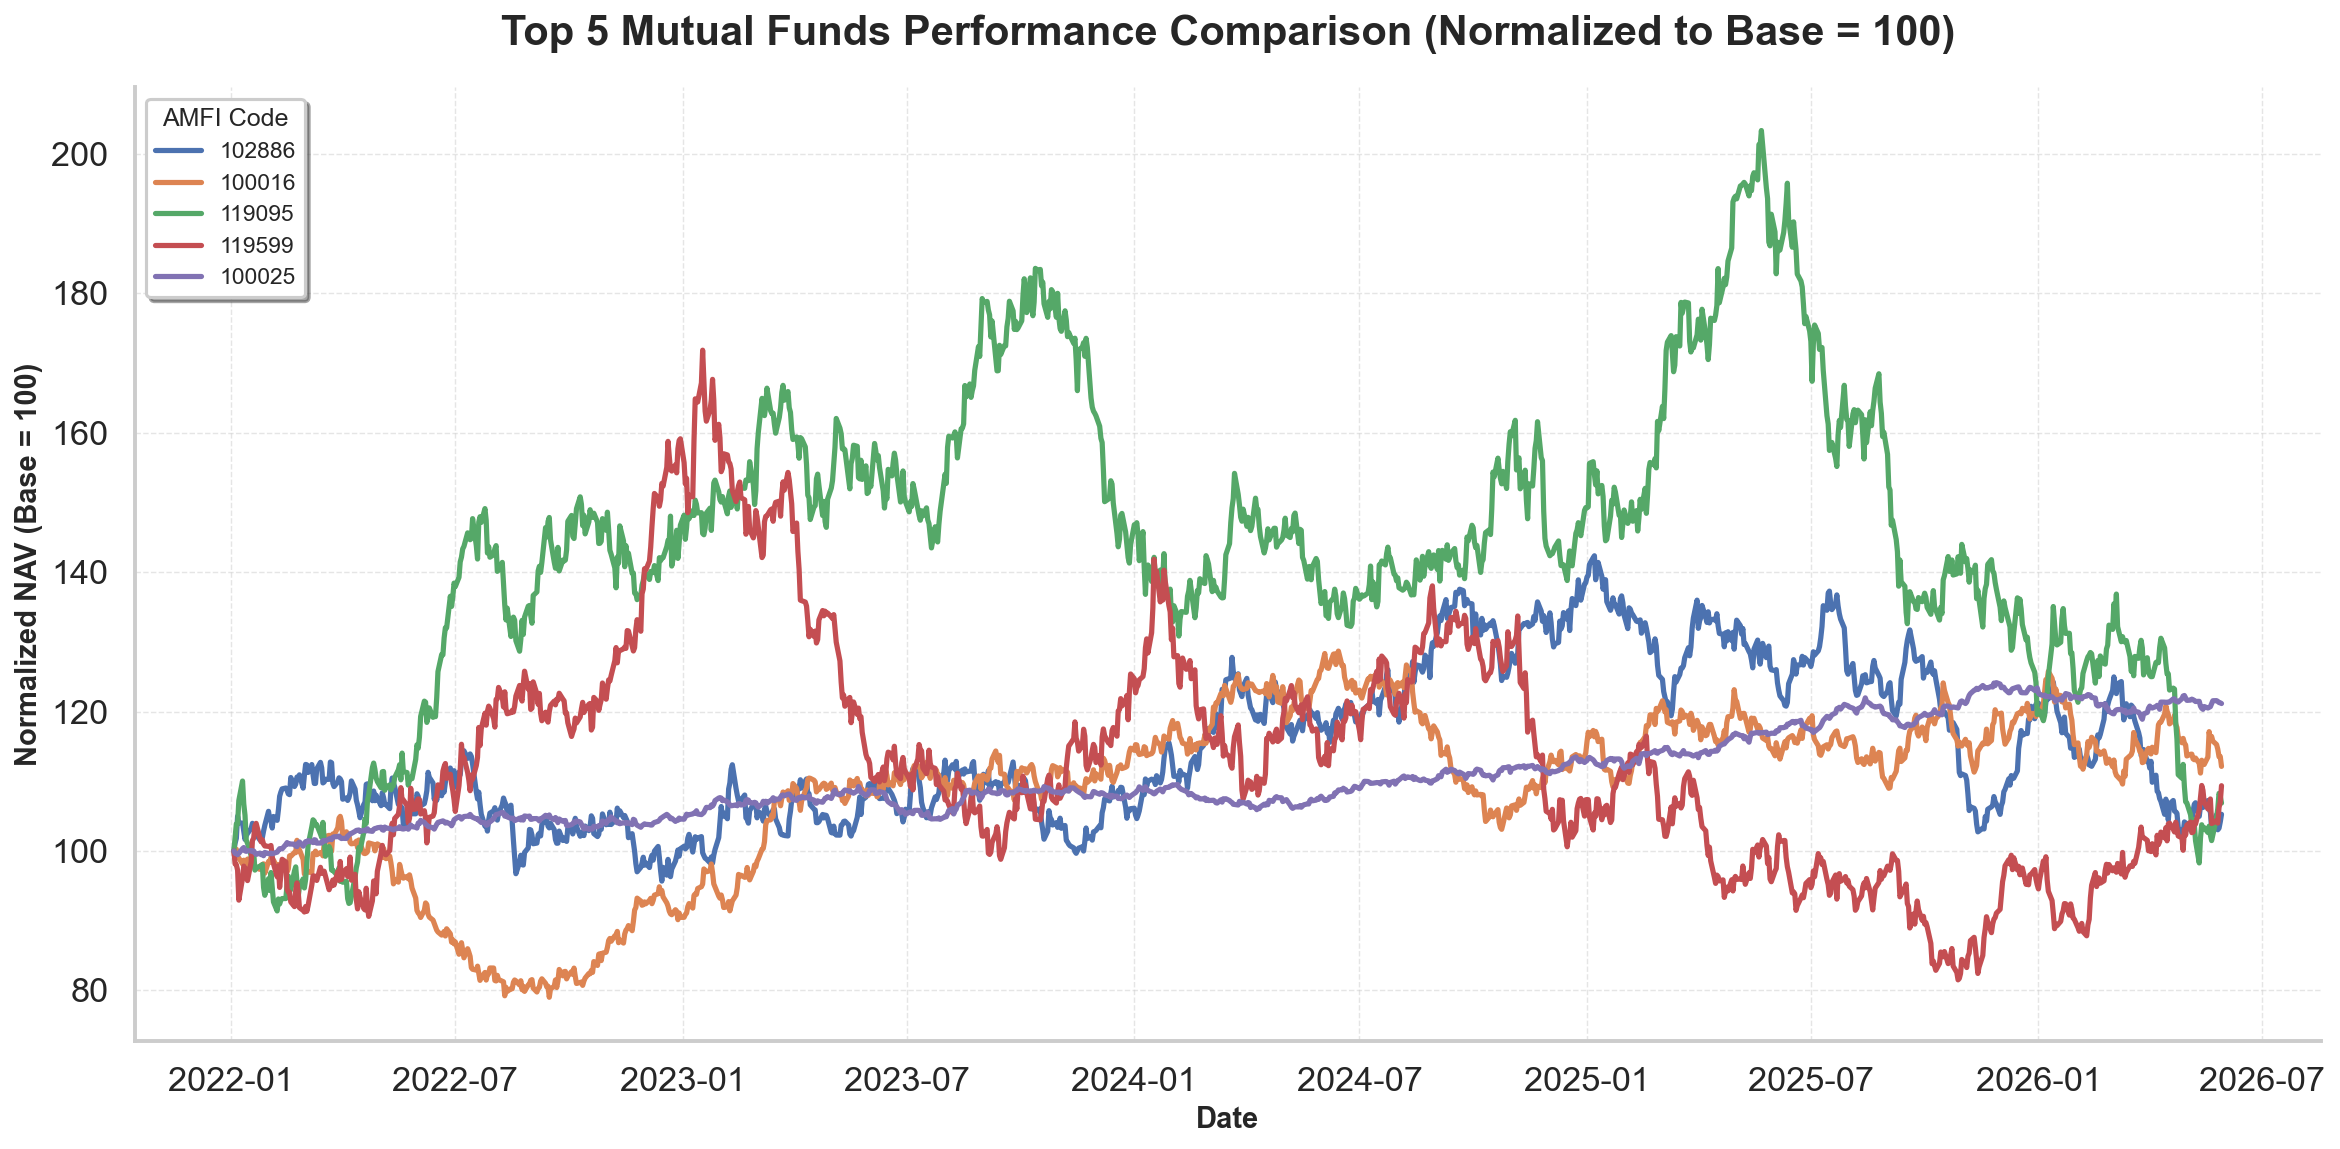

In [34]:
# Professional Benchmark Comparison Chart

import matplotlib.pyplot as plt
import seaborn as sns

# Professional styling
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(16, 8), dpi=150)

for fund in top5_funds:

    temp = top5_nav[top5_nav["amfi_code"] == fund].copy()

    # Normalize NAV to start at 100
    temp["normalized_nav"] = (
        temp["nav"] / temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        linewidth=2.5,
        label=str(fund)
    )

# Chart Title
plt.title(
    "Top 5 Mutual Funds Performance Comparison (Normalized to Base = 100)",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Axis Labels
plt.xlabel(
    "Date",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Normalized NAV (Base = 100)",
    fontsize=14,
    fontweight="bold"
)

# Legend
plt.legend(
    title="AMFI Code",
    fontsize=11,
    title_fontsize=12,
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True
)

# Grid
plt.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

# Remove top/right border
sns.despine()

# Improve spacing
plt.tight_layout()

# Save High Resolution
plt.savefig(
    "../reports/benchmark_chart.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()